__SV3 LRGs__

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
def binned_frac(x, y, bin_edges, minsize=10):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            p1 = np.maximum(p, 1/n)  # error floor
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

In [4]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS'])
idx = np.where(tmp['TARGETS']=='QSO+LRG')[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

674227
37119


In [5]:
deep = zbest.copy()

# Select deep coadds
mask = deep['subset']=='deep'
print(np.sum(mask))
# # Select QSO+LRG tiles
# mask &= deep['TARGETS']=='QSO+LRG'
# print(np.sum(mask))
deep = deep[mask]

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = deep['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# # Ting-Wen's quality cuts
# mask = deep['DELTACHI2']>20
# mask &= deep['Z']<1.4
# mask &= deep['ZWARN']==0
# print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# deep = deep[mask]

print(len(deep))
print(len(np.unique(deep['TARGETID'])))

deep_columns_old = ['Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR', 'EFFTIME_DARK', 'EFFTIME_BRIGHT', 'EFFTIME_BACK']
deep_columns_new = ['Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'SUBTYPE_deep', 'DELTACHI2_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep', 'EFFTIME_DARK_deep', 'EFFTIME_BRIGHT_deep', 'EFFTIME_BACK_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

34868
FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 24255 5115 0.8258426966292135
24255
24199


In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

In [7]:
mask = zbest['RZR']=='single_exposures'
zbest = zbest[mask]
print(len(zbest))

# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

print(len(np.unique(zbest['TARGETID'])))

deep_columns = deep_columns_new+['TARGETID', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'gfibermag', 'rfibermag', 'zfibermag']
zbest = join(zbest, deep[deep_columns], keys='TARGETID')

429668
FIBERSTATUS 348614 81054 0.18864332461342245
No data 348614 0 0.0
31055


In [8]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [9]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

########################################################################

# zfiber & sliding cut extension; 600 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.07) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.17) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.05) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.14) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.49
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_north = lrg_mask.copy()

lrg_sv3_lowdens = lrg_sv3_lowdens_south | lrg_sv3_lowdens_north
print(np.sum(lrg_sv3_lowdens))

108549
81083


In [10]:
mask_1x = (zbest['EFFTIME_DARK']>800) & (zbest['EFFTIME_DARK']<1200)
print(np.sum(lrg_sv3 & mask_1x))
print(np.sum(lrg_sv3_lowdens & mask_1x))

18022
13502


In [11]:
fail_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > fail_threshold

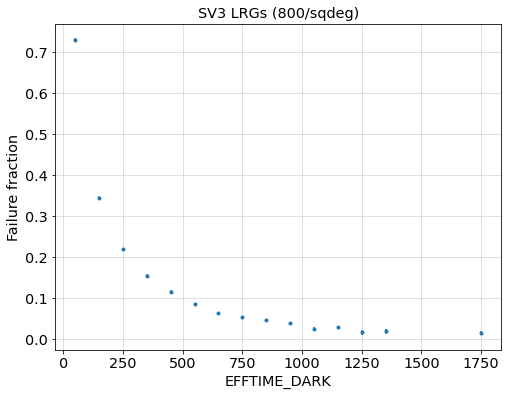

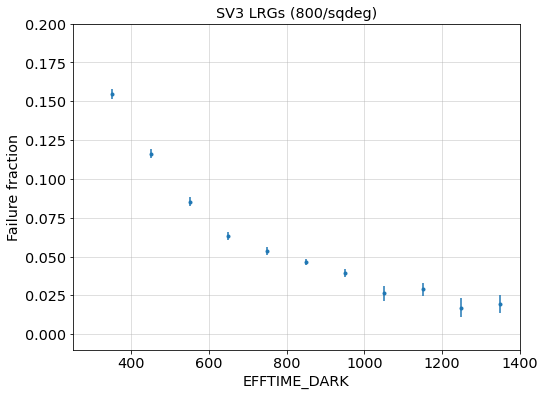

In [12]:
mask = lrg_sv3.copy()
bin_edges = np.linspace(0, 2000, 21)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(zbest['EFFTIME_DARK'][mask], mask_fail[mask], bin_edges, minsize=10)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate, 
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.')
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV3 LRGs (800/sqdeg)')
plt.show()

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate,
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.')
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV3 LRGs (800/sqdeg)')
plt.axis([250, 1400, -0.01, 0.2])
plt.show()

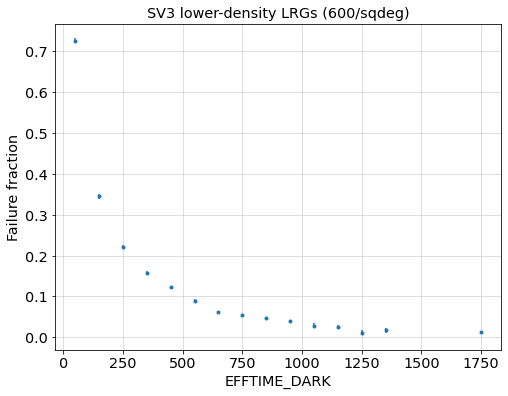

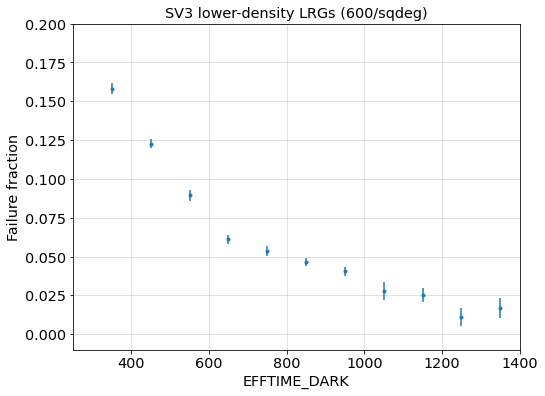

In [13]:
mask = lrg_sv3_lowdens.copy()
bin_edges = np.linspace(0, 2000, 21)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(zbest['EFFTIME_DARK'][mask], mask_fail[mask], bin_edges, minsize=10)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate, 
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.')
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV3 lower-density LRGs (600/sqdeg)')
plt.show()

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate,
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.')
plt.xlabel('EFFTIME_DARK')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV3 lower-density LRGs (600/sqdeg)')
plt.axis([250, 1400, -0.01, 0.2])
plt.show()

------
## TSNR2

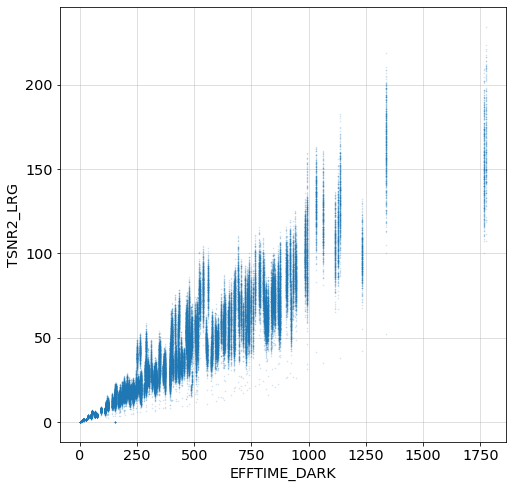

In [14]:
plt.figure(figsize=(8, 8))
plt.plot(zbest['EFFTIME_DARK'][lrg_sv3], zbest['TSNR2_LRG'][lrg_sv3], '.', ms=1, alpha=0.2)
plt.xlabel('EFFTIME_DARK')
plt.ylabel('TSNR2_LRG')
plt.grid(alpha=0.5)
plt.show()

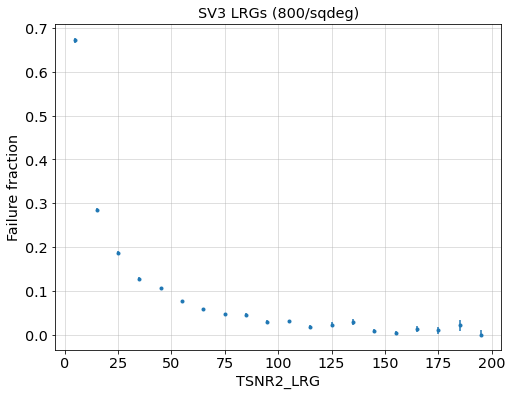

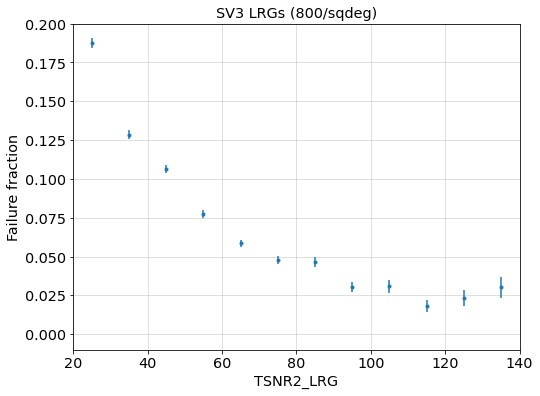

In [15]:
mask = lrg_sv3.copy()
bin_edges = np.linspace(0, 200, 21)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(zbest['TSNR2_LRG'][mask], mask_fail[mask], bin_edges, minsize=10)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate, 
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.')
plt.xlabel('TSNR2_LRG')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV3 LRGs (800/sqdeg)')
plt.show()

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate,
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.')
plt.xlabel('TSNR2_LRG')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
# plt.legend(loc='upper right')
plt.title('SV3 LRGs (800/sqdeg)')
plt.axis([20, 140, -0.01, 0.2])
plt.show()